In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.13.0+cu130
True
NVIDIA L4


In [2]:
import os
import json
import torch
import faiss
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm

import open_clip

/home/sanjnasuresh_umass_edu/.conda/envs/driving-clip/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

annotation_file = "driving_dataset_2k/_annotations.coco.json"

with open(annotation_file, "r") as f:
    coco = json.load(f)

class_mapping = {
    c["id"]: c["name"]
    for c in coco["categories"]
}

image_paths = [
    f"driving_dataset_2k/{img['file_name']}"
    for img in coco["images"]
]

print("Number of images:", len(image_paths))
print("Classes:", class_mapping)

Number of images: 2000
Classes: {0: 'obstacles', 1: 'biker', 2: 'car', 3: 'pedestrian', 4: 'trafficLight', 5: 'trafficLight-Green', 6: 'trafficLight-GreenLeft', 7: 'trafficLight-Red', 8: 'trafficLight-RedLeft', 9: 'trafficLight-Yellow', 10: 'trafficLight-YellowLeft', 11: 'truck'}


In [7]:
# ============================================================
# 3. LOAD CLIP
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

model = model.to(device)
model.eval()

print("Running on:", device)

Running on: cuda


In [8]:
# ============================================================
# 4. IMAGE EMBEDDING FUNCTION
# ============================================================

@torch.no_grad()
def encode_images(image_paths, batch_size=64):

    embeddings = []
    valid_paths = []

    for start in tqdm(range(0, len(image_paths), batch_size)):

        batch_paths = image_paths[start:start + batch_size]

        images = []
        successful_paths = []

        for path in batch_paths:
            try:
                image = Image.open(path).convert("RGB")
                image = preprocess(image)

                images.append(image)
                successful_paths.append(path)

            except Exception as e:
                print("Skipping:", path, e)

        if not images:
            continue

        batch = torch.stack(images).to(device)

        features = model.encode_image(batch)

        # VERY IMPORTANT:
        # normalize vectors so inner product = cosine similarity
        features = features / features.norm(
            dim=-1,
            keepdim=True
        )

        embeddings.append(
            features.cpu().numpy()
        )

        valid_paths.extend(successful_paths)

    embeddings = np.concatenate(
        embeddings,
        axis=0
    )

    return embeddings.astype("float32"), valid_paths

In [9]:
# Start with 10k
subset_paths = image_paths[:10]

image_embeddings, valid_paths = encode_images(
    subset_paths,
    batch_size=64
)

print(image_embeddings.shape)

100%|██████████| 1/1 [00:01<00:00,  1.92s/it]

(10, 512)


In [10]:
# ============================================================
# 5. SAVE RAW EMBEDDINGS
# ============================================================

os.makedirs("clip_store", exist_ok=True)

np.save(
    "clip_store/image_embeddings.npy",
    image_embeddings
)

pd.DataFrame({
    "vector_id": range(len(valid_paths)),
    "image_path": valid_paths
}).to_csv(
    "clip_store/image_metadata.csv",
    index=False
)

print("Saved.")

Saved.


In [11]:
# ============================================================
# 6. BUILD FAISS INDEX
# ============================================================

dimension = image_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(image_embeddings)

print("Vectors stored:", index.ntotal)

Vectors stored: 10


In [12]:
faiss.write_index(
    index,
    "clip_store/driving_clip.index"
)

In [13]:
# ============================================================
# 7. TEXT EMBEDDING
# ============================================================

@torch.no_grad()
def encode_text(text):

    tokens = tokenizer([text]).to(device)

    features = model.encode_text(tokens)

    features = features / features.norm(
        dim=-1,
        keepdim=True
    )

    return features.cpu().numpy().astype("float32")

In [14]:
# ============================================================
# 8. SEARCH
# ============================================================

def search_images(query, k=5):

    query_embedding = encode_text(query)

    scores, indices = index.search(
        query_embedding,
        k
    )

    results = []

    for score, idx in zip(scores[0], indices[0]):

        results.append({
            "image_path": valid_paths[idx],
            "similarity": float(score)
        })

    return results

In [15]:
results = search_images(
    "a pedestrian crossing the road",
    k=5
)

results

[{'image_path': 'driving_dataset_2k/1478732320379283754_jpg.rf.XAb6FgGQlikWLf7uaJlc.jpg',
  'similarity': 0.2847323715686798},
 {'image_path': 'driving_dataset_2k/1478897939548344386_jpg.rf.65f63f2e09ecc105a828fc5243022dd5.jpg',
  'similarity': 0.28127986192703247},
 {'image_path': 'driving_dataset_2k/1478021633083910147_jpg.rf.15f93feaaf39dc81a4ea2dff2e84733a.jpg',
  'similarity': 0.2634689211845398},
 {'image_path': 'driving_dataset_2k/1478900984522923814_jpg.rf.957e827360280e683d88aa41961d7267.jpg',
  'similarity': 0.26047804951667786},
 {'image_path': 'driving_dataset_2k/1478898052093813142_jpg.rf.9HmSxKoa75wFj3EuoCKs.jpg',
  'similarity': 0.2534090280532837}]

In [16]:
import matplotlib.pyplot as plt

def show_results(query, k=5):

    results = search_images(query, k)

    plt.figure(figsize=(15, 4))

    for i, result in enumerate(results):

        image = Image.open(
            result["image_path"]
        ).convert("RGB")

        plt.subplot(1, k, i + 1)

        plt.imshow(image)
        plt.axis("off")

        plt.title(
            f"{result['similarity']:.3f}"
        )

    plt.suptitle(query)

    plt.show()

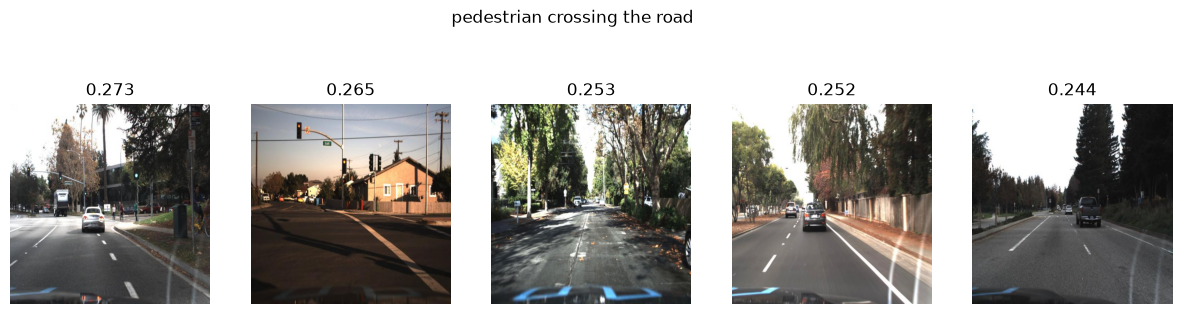

In [17]:
show_results(
    "pedestrian crossing the road",
    k=5
)